#Predicting how long a jet engine has left to live
### Remaining Useful Life (RUL) prediction on NASA C-MAPSS

##Import libraries

In [1]:
import urllib.request, os            #for downloading files or data
import numpy as np                   #for numerical calculations and
import pandas as pd                  #for dataset
import matplotlib.pyplot as plt      #for visualising
import torch
import torch.nn as nn                # Neural network layers

torch.manual_seed(42)
np.random.seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


##Download NASA C-MAPSS dataset


In [2]:
os.makedirs("data", exist_ok=True)
base = "https://raw.githubusercontent.com/cyrilli/TurboEngine_Dataset_NASA/master/CMAPSSData"
for name in ["train_FD001.txt", "test_FD001.txt", "RUL_FD001.txt"]:
    if not os.path.exists(f"data/{name}"):
        urllib.request.urlretrieve(f"{base}/{name}", f"data/{name}")
print("Data ready:", os.listdir("data"))

Data ready: ['test_FD001.txt', 'train_FD001.txt', 'RUL_FD001.txt']


##Load the data

In [3]:
columns = ["unit", "cycle"] + [f"op{i}" for i in range(1, 4)] + [f"s{i}" for i in range(1, 22)]

train_df = pd.read_csv("data/train_FD001.txt", sep=r"\s+", header=None, names=columns)
test_df  = pd.read_csv("data/test_FD001.txt",  sep=r"\s+", header=None, names=columns)
rul_true = pd.read_csv("data/RUL_FD001.txt", sep=r"\s+", header=None)[0].to_numpy()

print("train:", train_df.shape, "| engines:", train_df["unit"].nunique())
print("test :", test_df.shape,  "| engines:", test_df["unit"].nunique())
train_df.head()

train: (20631, 26) | engines: 100
test : (13096, 26) | engines: 100


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


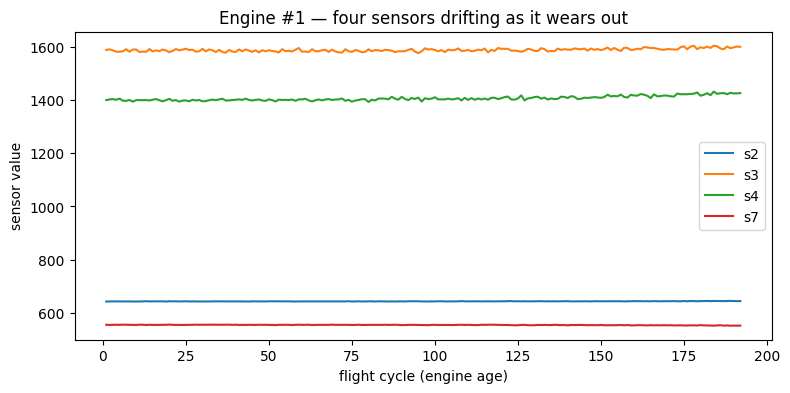

In [5]:
# Select data for engine 1

engine1 = train_df[train_df["unit"] == 1]
plt.figure(figsize=(9, 4))
for s in ["s2", "s3", "s4", "s7"]:
    plt.plot(engine1["cycle"], engine1[s], label=s)
plt.xlabel("flight cycle (engine age)"); plt.ylabel("sensor value")
plt.title("Engine #1 — four sensors drifting as it wears out"); plt.legend(); plt.show()

##Create the labels (RUL)

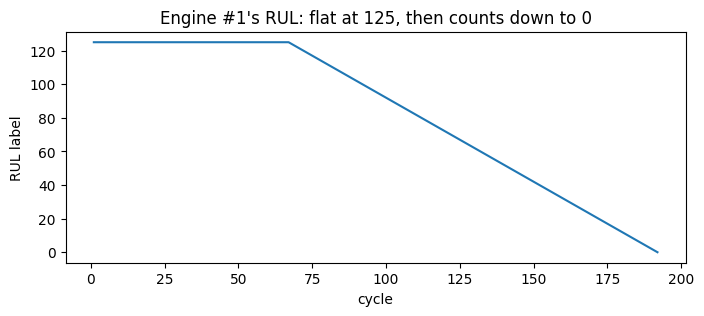

In [6]:
# Set the maximum RUL value
RUL_CAP = 125

# Find the last cycle of each engine
last_cycle = train_df.groupby("unit")["cycle"].transform("max")
train_df["RUL"] = (last_cycle - train_df["cycle"]).clip(upper=RUL_CAP)

# Calculate the RUL value
plt.figure(figsize=(8, 3))
plt.plot(engine1["cycle"], (engine1["cycle"].max() - engine1["cycle"]).clip(upper=RUL_CAP))
plt.xlabel("cycle"); plt.ylabel("RUL label")
plt.title("Engine #1's RUL: flat at 125, then counts down to 0"); plt.show()

##Keep the useful sensors and rescale

In [7]:
sensor_cols = [c for c in columns if c.startswith("s") or c.startswith("op")]
features = [c for c in sensor_cols if train_df[c].std() > 1e-6]     # drop constant sensors
print("kept", len(features), "of", len(sensor_cols), "sensors")

low, high = train_df[features].min(), train_df[features].max()
train_df[features] = (train_df[features] - low) / (high - low)
test_df[features]  = ((test_df[features] - low) / (high - low)).clip(0, 1)

kept 17 of 24 sensors


##Cut each engine's history into fixed 30-flight windows


In [8]:
WINDOW = 30

def make_train_windows(df, features, window=WINDOW):
    X, y = [], []
    for _, group in df.groupby("unit"):
        data = group[features].to_numpy("float32")
        ruls = group["RUL"].to_numpy("float32")
        for i in range(len(data) - window + 1):
            X.append(data[i:i + window])
            y.append(ruls[i + window - 1])
    return np.array(X), np.array(y)

def make_test_windows(df, features, rul_values, window=WINDOW):
    X = []
    for _, group in df.groupby("unit"):
        data = group[features].to_numpy("float32")
        if len(data) < window:                          # pad very short engines
            pad = np.repeat(data[:1], window - len(data), axis=0)
            data = np.concatenate([pad, data])
        X.append(data[-window:])
    y = np.minimum(rul_values, RUL_CAP).astype("float32")
    return np.array(X), y

X_train, y_train = make_train_windows(train_df, features)
X_test,  y_test  = make_test_windows(test_df, features, rul_true)
print("train windows:", X_train.shape, "| test windows:", X_test.shape)

train windows: (17731, 30, 17) | test windows: (100, 30, 17)


##2 ways to score a prediction


In [11]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

def nasa_score(y_true, y_pred):
    d = y_pred - y_true                       # d<0 early (safe), d>0 late (dangerous)
    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))

##Comparision of 4 models
LSTM, GRU, 1D-CNN, Transformers

In [12]:
class LSTMNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.lstm = nn.LSTM(n_features, 64, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1]).squeeze(-1)        # use the last step's memory

class GRUNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.gru = nn.GRU(n_features, 64, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1]).squeeze(-1)

class CNNNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.conv1 = nn.Conv1d(n_features, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        x = x.transpose(1, 2)                         # -> (batch, features, time)
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        return self.fc(x.mean(dim=2)).squeeze(-1)     # average over time

class TransformerNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.proj = nn.Linear(n_features, 64)
        self.pos = nn.Parameter(torch.zeros(1, WINDOW, 64))
        layer = nn.TransformerEncoderLayer(64, nhead=4, dim_feedforward=128, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=2)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        x = self.encoder(self.proj(x) + self.pos)
        return self.fc(x.mean(dim=1)).squeeze(-1)

##training


In [13]:
BATCH = 256
EPOCHS = 40

def train_model(model, X, y, epochs=EPOCHS):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    X = torch.tensor(X); y = torch.tensor(y)
    for epoch in range(epochs):
        model.train()
        order = torch.randperm(len(X))                 # shuffle each epoch
        for i in range(0, len(X), BATCH):
            batch = order[i:i + BATCH]
            xb, yb = X[batch].to(device), y[batch].to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f"    epoch {epoch + 1:2d}/{epochs}  last-batch loss {loss.item():.1f}")
    return model

def predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X).to(device)).cpu().numpy()

##train all four models


In [14]:
models = {"LSTM": LSTMNet(len(features)), "GRU": GRUNet(len(features)),
          "1D-CNN": CNNNet(len(features)), "Transformer": TransformerNet(len(features))}

results, predictions = {}, {}
for name, model in models.items():
    print(f"Training {name} ...")
    trained = train_model(model, X_train, y_train)
    pred = np.clip(predict(trained, X_test), 0, RUL_CAP)
    predictions[name] = pred
    results[name] = {"params": sum(p.numel() for p in trained.parameters()),
                     "RMSE": rmse(y_test, pred), "NASA": nasa_score(y_test, pred)}
    print(f"  -> {name}: RMSE {results[name]['RMSE']:.2f}, NASA {results[name]['NASA']:.0f}\n")

Training LSTM ...
    epoch 10/40  last-batch loss 2947.0
    epoch 20/40  last-batch loss 2243.3
    epoch 30/40  last-batch loss 1955.4
    epoch 40/40  last-batch loss 2207.9
  -> LSTM: RMSE 40.51, NASA 17952

Training GRU ...
    epoch 10/40  last-batch loss 2840.2
    epoch 20/40  last-batch loss 1769.1
    epoch 30/40  last-batch loss 1764.9
    epoch 40/40  last-batch loss 1665.1
  -> GRU: RMSE 40.51, NASA 17911

Training 1D-CNN ...
    epoch 10/40  last-batch loss 542.7
    epoch 20/40  last-batch loss 416.7
    epoch 30/40  last-batch loss 482.5
    epoch 40/40  last-batch loss 389.1
  -> 1D-CNN: RMSE 20.87, NASA 2974

Training Transformer ...
    epoch 10/40  last-batch loss 327.3
    epoch 20/40  last-batch loss 194.3
    epoch 30/40  last-batch loss 142.8
    epoch 40/40  last-batch loss 121.9
  -> Transformer: RMSE 15.47, NASA 453



##Results

In [16]:
table = pd.DataFrame([
    {"Model": name, "Params": r["params"],
     "Test RMSE": round(r["RMSE"], 2), "NASA Score": round(r["NASA"], 1)}
    for name, r in results.items()
]).sort_values("Test RMSE").reset_index(drop=True)
print(table.to_string(index=False))

      Model  Params  Test RMSE  NASA Score
Transformer   70081      15.47       452.6
     1D-CNN   17921      20.87      2973.8
        GRU   40961      40.51     17911.2
       LSTM   54593      40.51     17951.9


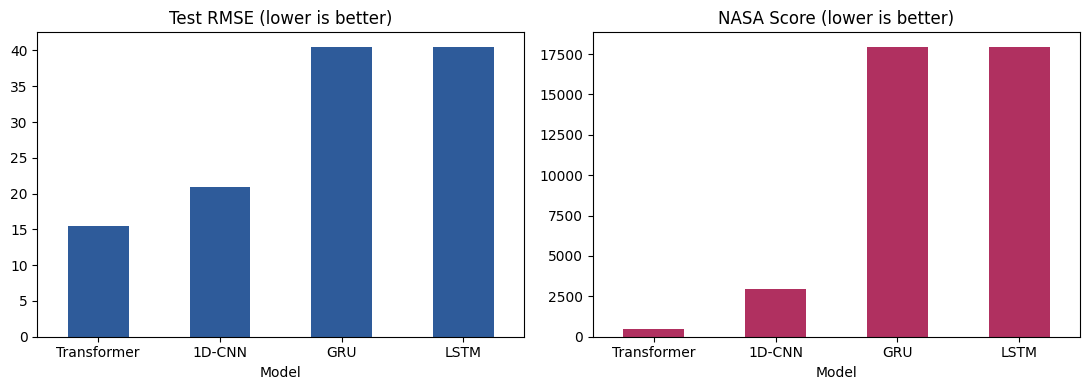

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
table.plot.bar(x="Model", y="Test RMSE", ax=ax[0], legend=False, color="#2E5B9A")
ax[0].set_title("Test RMSE (lower is better)")
table.plot.bar(x="Model", y="NASA Score", ax=ax[1], legend=False, color="#B03060")
ax[1].set_title("NASA Score (lower is better)")
for a in ax: a.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

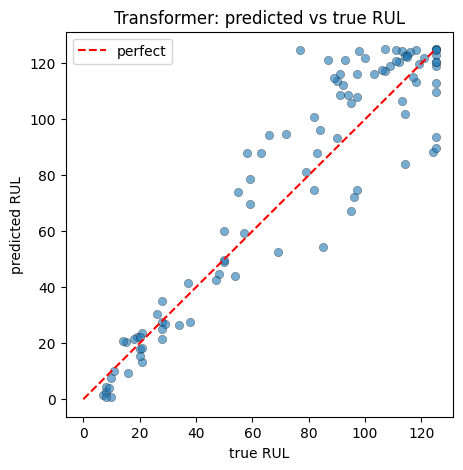

In [20]:
best = table["Model"].iloc[0]
plt.figure(figsize=(5, 5))
plt.scatter(y_test, predictions[best], alpha=0.6, edgecolor="k", linewidth=0.3)
plt.plot([0, RUL_CAP], [0, RUL_CAP], "r--", label="perfect")
plt.xlabel("true RUL"); plt.ylabel("predicted RUL")
plt.title(f"{best}: predicted vs true RUL"); plt.legend(); plt.show()